In [23]:
from langgraph.graph import MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

In [24]:
load_dotenv()

True

In [25]:
model = ChatOpenAI()

In [8]:
class ChatState(MessagesState):
    summary: str

In [26]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
        
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [27]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [28]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [29]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")



In [31]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

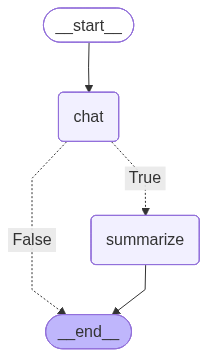

In [32]:
graph

In [33]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [34]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [35]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='a19f9f7a-720f-44b2-a5c9-c139b2ad7a43')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics is a branch of physics that deals with the behavior of matter an


In [36]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='a19f9f7a-720f-44b2-a5c9-c139b2ad7a43'), AIMessage(content='Quantum physics is a branch of physics that deals with the behavior of matter and energy on the smallest scales of atoms and subatomic particles. It involves principles such as quantization of energy, wave-particle duality, and the uncertainty principle. Quantum physics has revolutionized our understanding of the fundamental nature of reality and has led to the development of technologies such as quantum computing and quantum cryptography. It also plays a key role in understanding the behavior of matter at extremely high energies, such as in particle accelerators and the early universe.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 106, 'prompt_tokens': 10, 'total_tokens': 116, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_p

In [37]:
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='a19f9f7a-720f-44b2-a5c9-c139b2ad7a43'), AIMessage(content='Quantum physics is a branch of physics that deals with the behavior of matter and energy on the smallest scales of atoms and subatomic particles. It involves principles such as quantization of energy, wave-particle duality, and the uncertainty principle. Quantum physics has revolutionized our understanding of the fundamental nature of reality and has led to the development of technologies such as quantum computing and quantum cryptography. It also plays a key role in understanding the behavior of matter at extremely high energies, such as in particle accelerators and the early universe.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 106, 'prompt_tokens': 10, 'total_tokens': 116, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_p

AuthenticationError: Error code: 401 - {'error': {'message': "You have insufficient permissions for this operation. Missing scopes: model.request. Check that you have the correct role in your organization (Reader, Writer, Owner) and project (Member, Owner), and if you're using a restricted API key, that it has the necessary scopes.", 'type': 'invalid_request_error', 'param': None, 'code': 'missing_scope'}}

In [38]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='a19f9f7a-720f-44b2-a5c9-c139b2ad7a43'), AIMessage(content='Quantum physics is a branch of physics that deals with the behavior of matter and energy on the smallest scales of atoms and subatomic particles. It involves principles such as quantization of energy, wave-particle duality, and the uncertainty principle. Quantum physics has revolutionized our understanding of the fundamental nature of reality and has led to the development of technologies such as quantum computing and quantum cryptography. It also plays a key role in understanding the behavior of matter at extremely high energies, such as in particle accelerators and the early universe.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 106, 'prompt_tokens': 10, 'total_tokens': 116, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_p